# Miniproject 2 - Creating a ZCB Term Structure

**FRE 6103 Valuation for Financial Engineering (NYU Tandon)** | Raj Pawar

Fit a continuously compounded zero-coupon (ZCB) term structure to all US Treasury note and bond quotes
(WSJ, Sep 4, 2026) with the Svensson (1994) functional form, and report the discount rate for every
Treasury payment date. The reusable code lives in the `zcb` package next to this notebook
(`python/zcb/`); this notebook walks through the pipeline and shows the results.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path("../python").resolve()))
from zcb import (load_wsj_quotes, settlement_date_for, check_conventions, prepare_bonds,
                 fit_term_structure, payment_date_table, profile_beta0)
from zcb.report import plot_zero_curve, plot_residuals, plot_discount_factors

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
DATA = Path("../data/Treasury_data_090426.xlsx")
OUT = Path("../output"); (OUT / "figures").mkdir(parents=True, exist_ok=True)

## 1. Data: WSJ Treasury notes and bonds

Prices are quoted in 32nds; the third decimal is eighths of a 32nd (`99.256` = 99 + 25.75/32).
Regular-way settlement is T+1 business days: the quote is Friday Sep 4, 2026, Monday Sep 7 is Labor Day,
so settlement is Tuesday Sep 8, 2026.

In [2]:
sheet = load_wsj_quotes(DATA)
settlement = settlement_date_for(sheet.quote_date)
print(f"Quote date {sheet.quote_date} | settlement {settlement} | {len(sheet.quotes)} bonds")
sheet.quotes.head(8)

Quote date 2026-09-04 | settlement 2026-09-08 | 353 bonds


,maturity,coupon,bid_quote,ask_quote,chg,asked_yield,bid_price,ask_price,mid_price
0,2026-09-15,4.625,100.000,100.010,-0.002,2.937,100.000000,100.031250,100.015625
1,2026-09-30,0.875,99.256,99.266,0.01,3.625,99.804688,99.835938,99.820312
2,2026-09-30,1.625,99.276,99.286,0.004,3.318,99.867188,99.898438,99.882812
3,2026-09-30,3.500,99.306,99.316,0.002,3.603,99.960938,99.992188,99.976562
4,2026-10-15,4.625,100.022,100.032,-0.002,3.576,100.070312,100.101562,100.085938
5,2026-10-31,1.125,99.186,99.196,0.01,3.808,99.585938,99.617188,99.601562
6,2026-10-31,1.625,99.212,99.222,0.008,3.755,99.664062,99.695312,99.679688
7,2026-10-31,4.125,100.000,100.010,-0.006,3.877,100.000000,100.031250,100.015625


### Convention check
We recompute each bond's asked yield under alternative settlement rules and price readings and compare
with the WSJ *Asked yield* column. Regular-way settlement with the 32nds+eighths reading reproduces the
WSJ yields to a median of a few hundredths of a basis point.

In [3]:
conventions = check_conventions(sheet.quotes, sheet.quote_date)
conventions.round(3)

,settlement_rule,settlement,price_format,rmse_bp,median_abs_bp,max_abs_bp
0,T+1 business (regular way),2026-09-08,32nds + eighths,0.511,0.025,2.854
1,T+1 business (regular way),2026-09-08,32nds + tenths,0.579,0.065,5.409
2,T+2 business,2026-09-09,32nds + eighths,1.781,0.053,28.874
3,T+2 business,2026-09-09,32nds + tenths,2.124,0.108,28.874
4,T+1 calendar,2026-09-05,32nds + tenths,3.452,0.092,46.259
5,T+1 calendar,2026-09-05,32nds + eighths,3.829,0.121,46.259
6,T+0 (quote date),2026-09-04,32nds + tenths,4.408,0.127,56.530
7,T+0 (quote date),2026-09-04,32nds + eighths,4.782,0.154,56.530
8,T+0 (quote date),2026-09-04,plain decimal,86.220,7.405,941.918
9,T+1 calendar,2026-09-05,plain decimal,89.820,7.436,979.993


## 2. Bond mechanics
Coupon schedule (month-end rule), actual/actual accrued interest, dirty price, Treasury street yield
and modified duration for every bond. Bonds with under 3 months to maturity are flagged `in_fit = False`
(money-market segment, following Gurkaynak-Sack-Wright 2007) and kept as an out-of-sample check.

In [4]:
bonds = prepare_bonds(sheet.quotes, settlement, price_side="ask")
cols = ["label", "clean_price", "accrued_interest", "dirty_price", "street_yield_pct", "wsj_asked_yield",
        "modified_duration", "n_cash_flows", "in_fit"]
print(f"{bonds.table.in_fit.sum()} of {len(bonds.table)} bonds enter the fit")
bonds.table[cols].iloc[[0, 5, 50, 150, 250, 352]].round(4)

339 of 353 bonds enter the fit


,label,clean_price,accrued_interest,dirty_price,street_yield_pct,wsj_asked_yield,modified_duration,n_cash_flows,in_fit
0,4.625% 2026-09-15,100.0312,2.2245,102.2558,2.9164,2.937,0.0187,1,False
5,1.125% 2026-10-31,99.6172,0.4005,100.0177,3.7824,3.808,0.1413,1,False
50,6.375% 2027-08-15,101.9609,0.4158,102.3767,4.2096,4.210,0.9005,2,True
150,3.500% 2029-09-30,97.2891,1.5396,98.8287,4.4568,4.457,2.8185,7,True
250,4.375% 2036-05-15,96.9414,1.3791,98.3205,4.7723,4.772,7.6724,20,True
352,5.125% 2056-08-15,98.2500,0.3342,98.5842,5.2412,5.241,15.0428,60,True


## 3. Model and estimation

Continuously compounded zero rate (Svensson 1994):

$$r(t)=\beta_0+\beta_1\frac{1-e^{-t/\tau_1}}{t/\tau_1}+\beta_2\left(\frac{1-e^{-t/\tau_1}}{t/\tau_1}-e^{-t/\tau_1}\right)+\beta_3\left(\frac{1-e^{-t/\tau_2}}{t/\tau_2}-e^{-t/\tau_2}\right)$$

Discount factor $d(t)=e^{-r(t)t}$; model dirty price of bond $i$ is $\sum_k CF_{ik}\,d(t_{ik})$.
Parameters minimise $\sum_i \big[(P_i^{model}-P_i^{market})/D_i\big]^2$ (price errors scaled by modified
duration, i.e. yield errors to first order), from 19 starting points on a $(\tau_1,\tau_2)$ grid, with
$\beta_0\ge 0$. Nelson-Siegel ($\beta_3=0$) is fitted as a benchmark.

In [5]:
svensson = fit_term_structure(bonds, "svensson")
nelson_siegel = fit_term_structure(bonds, "nelson_siegel")
summary = pd.DataFrame([svensson.summary, nelson_siegel.summary]).set_index("model")
summary[["n_bonds_in_fit", "weighted_sse", "price_rmse", "yield_rmse_bp", "yield_mae_bp", "yield_max_abs_bp",
         "n_starts", "n_starts_at_optimum"]].round(4)

,n_bonds_in_fit,weighted_sse,price_rmse,yield_rmse_bp,yield_mae_bp,yield_max_abs_bp,n_starts,n_starts_at_optimum
model,,,,,,,,
svensson,339,0.2613,0.1853,2.8823,2.0775,14.8179,19,15
nelson_siegel,339,1.8318,0.3884,7.5413,5.8930,38.5285,4,4


In [6]:
pd.Series(svensson.summary["params"], name="Svensson parameters").to_frame().round(6)

,Svensson parameters
beta0,0.000000
beta1,0.036276
beta2,0.044722
beta3,0.162287
tau1,1.766099
tau2,15.991117


## 4. Deliverable: discount rate for every Treasury payment date

In [7]:
payments = payment_date_table(bonds, svensson.fit.params)
payments.to_csv(OUT / "zero_curve_payment_dates.csv", index=False)
print(f"{len(payments)} distinct payment dates, {payments.payment_date.iloc[0]} to {payments.payment_date.iloc[-1]}")
pd.concat([payments.head(10), payments.tail(5)]).round(6)

245 distinct payment dates, 2026-09-15 to 2056-08-15


,payment_date,days,t_years,zero_rate_cc_pct,discount_factor,inst_forward_cc_pct
0,2026-09-15,7,0.019178,3.641832,0.999302,3.655926
1,2026-09-30,22,0.060274,3.671530,0.997789,3.714357
2,2026-10-15,37,0.101370,3.700242,0.996256,3.769871
3,2026-10-31,53,0.145205,3.729813,0.994599,3.826004
4,2026-11-15,68,0.186301,3.756579,0.993026,3.875856
5,2026-11-30,83,0.227397,3.782445,0.991436,3.923137
6,2026-12-15,98,0.268493,3.807440,0.989829,3.967951
7,2026-12-31,114,0.312329,3.833170,0.988099,4.013147
8,2027-01-15,129,0.353425,3.856447,0.986463,4.053179
9,2027-01-31,145,0.397260,3.880401,0.984703,4.093493


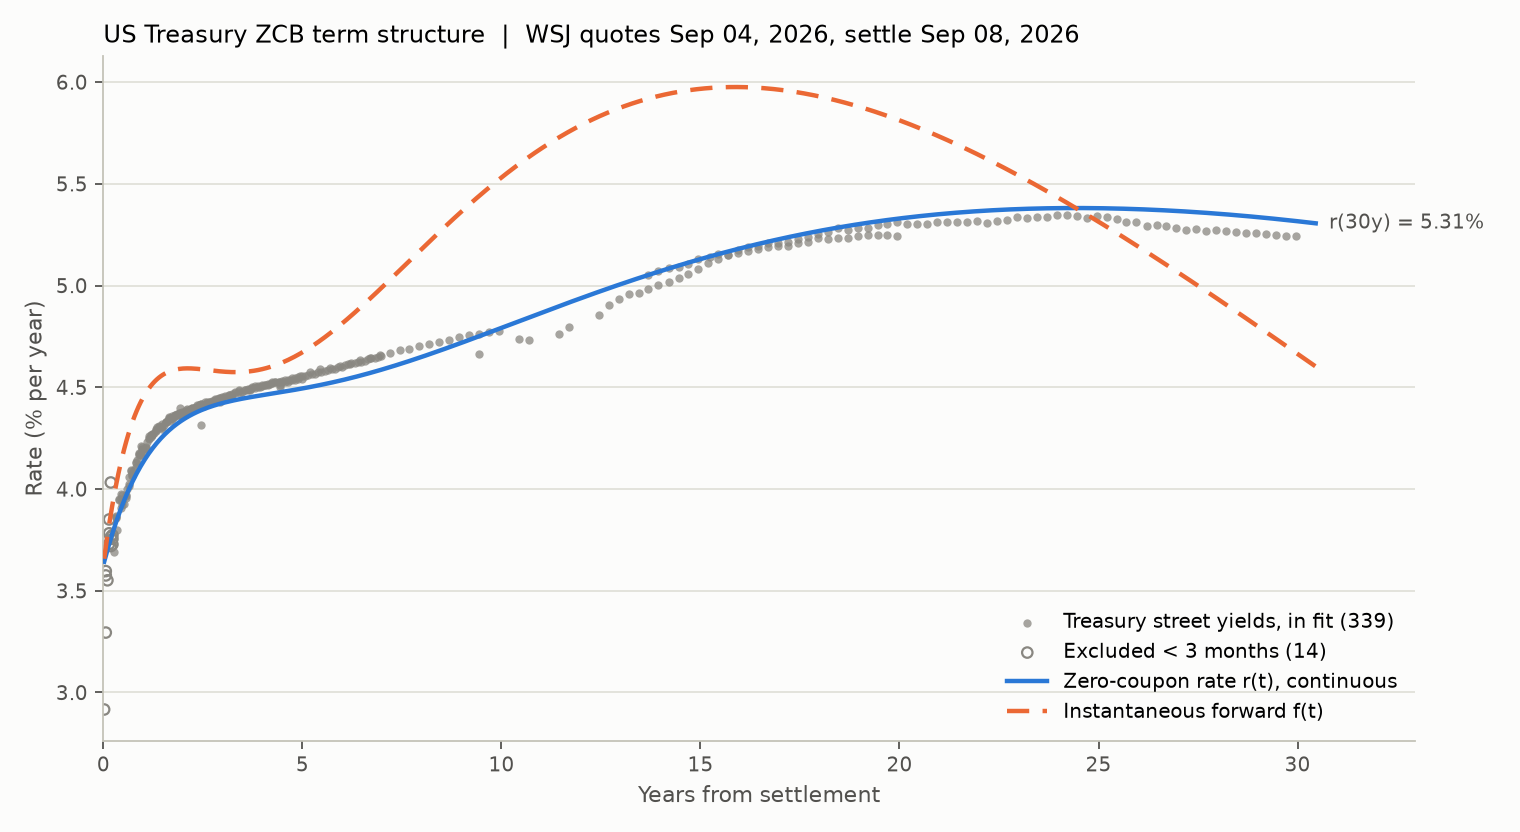

In [8]:
plot_zero_curve(svensson.bond_table, svensson.fit.params, sheet.quote_date, settlement, OUT / "figures/zero_curve.png")
display(Image(OUT / "figures/zero_curve.png", width=900))

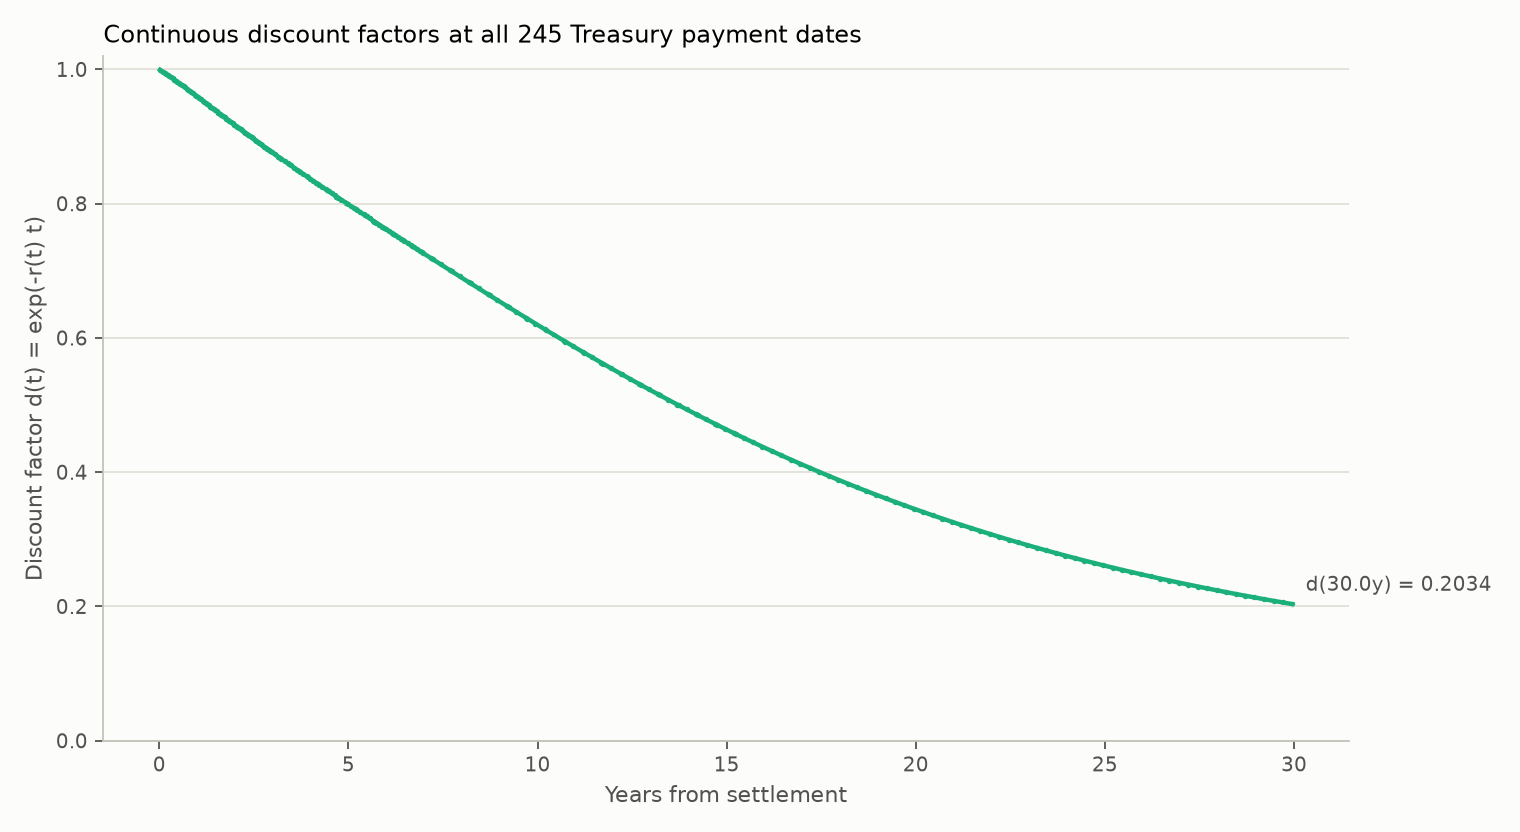

In [9]:
plot_discount_factors(payments, OUT / "figures/discount_factors.png")
display(Image(OUT / "figures/discount_factors.png", width=900))

## 5. Fit quality

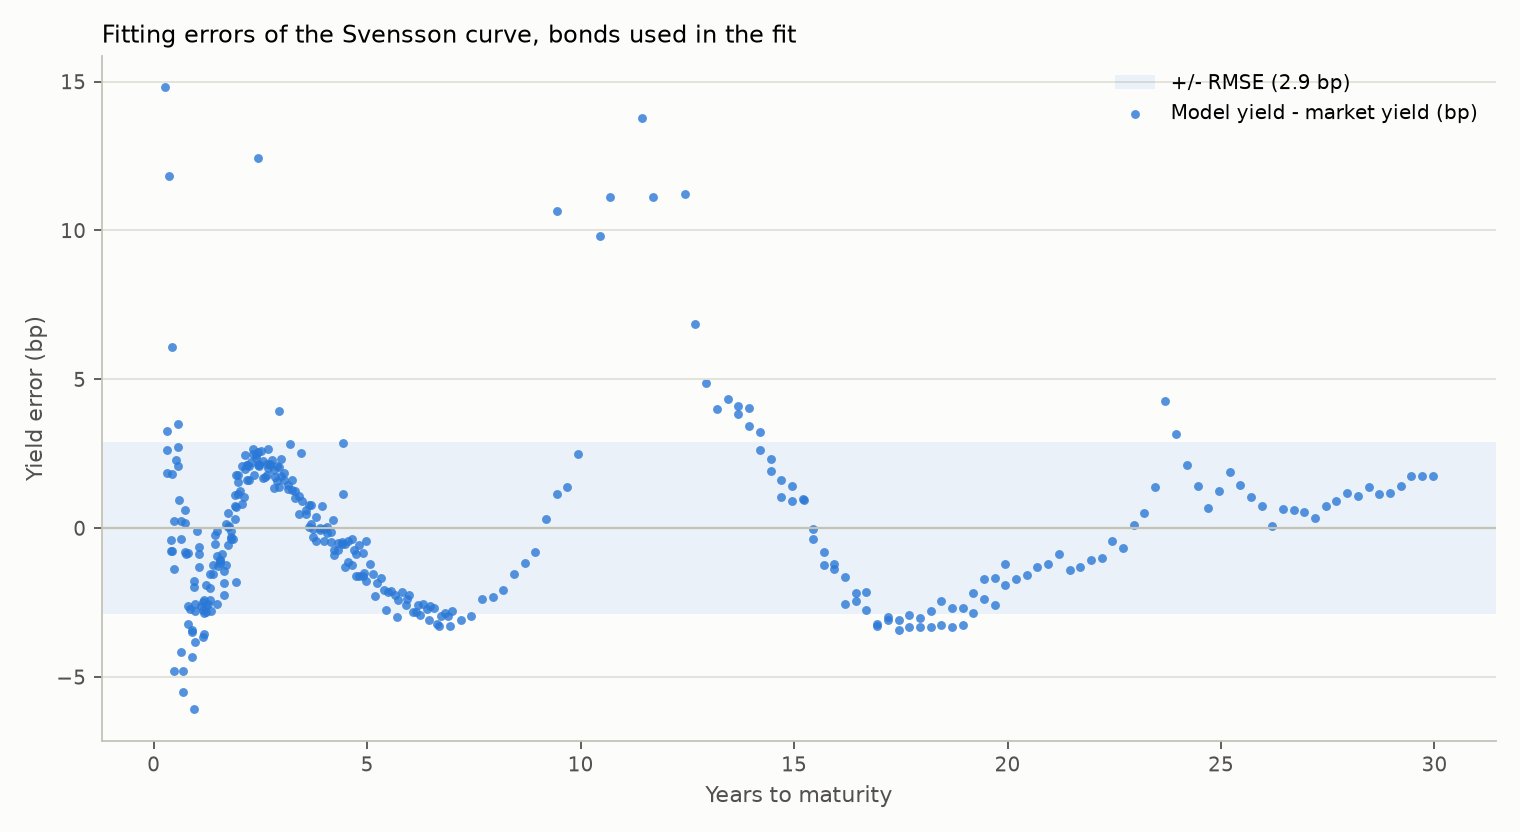

,n,mean,std,max_abs
bucket,,,,
"(0.25, 1.0]",40,-0.23,4.20,14.82
"(1.0, 2.0]",53,-1.03,1.37,3.66
"(2.0, 3.0]",43,2.28,1.67,12.45
"(3.0, 5.0]",57,0.09,1.11,2.87
"(5.0, 7.0]",32,-2.52,0.51,3.30
"(7.0, 10.0]",13,-0.03,3.66,10.66
"(10.0, 20.0]",61,0.31,4.28,13.77
"(20.0, 31.0]",40,0.60,1.33,4.28


In [10]:
plot_residuals(svensson.bond_table, svensson.summary, OUT / "figures/yield_residuals.png")
display(Image(OUT / "figures/yield_residuals.png", width=900))
tbl = svensson.bond_table
tbl["bucket"] = pd.cut(tbl.years_to_maturity, [0, 0.25, 1, 2, 3, 5, 7, 10, 20, 31])
tbl[tbl.in_fit].groupby("bucket", observed=True).yield_error_bp.agg(
    n="count", mean="mean", std="std", max_abs=lambda s: s.abs().max()).round(2)

In [11]:
print("Largest yield errors among fitted bonds:")
tbl[tbl.in_fit].reindex(tbl[tbl.in_fit].yield_error_bp.abs().sort_values(ascending=False).index)[
    ["label", "years_to_maturity", "clean_price", "street_yield_pct", "model_yield_pct", "yield_error_bp", "price_error"]].head(6).round(4)

Largest yield errors among fitted bonds:


,label,years_to_maturity,clean_price,street_yield_pct,model_yield_pct,yield_error_bp,price_error
14,4.375% 2026-12-15,0.2685,100.1719,3.6893,3.8375,14.8179,-0.0397
254,4.375% 2038-02-15,11.4466,96.6250,4.7608,4.8986,13.7724,-1.1704
126,5.250% 2029-02-15,2.4411,102.1406,4.3130,4.4375,12.4479,-0.2882
18,4.000% 2027-01-15,0.3534,100.0625,3.7966,3.9148,11.8126,-0.0411
256,3.500% 2039-02-15,12.4466,87.4375,4.8575,4.9696,11.2102,-0.9505
255,4.500% 2038-05-15,11.6904,97.3516,4.7980,4.9092,11.1194,-0.9641


In [12]:
print("Out-of-sample: bonds under 3 months excluded from the fit")
tbl[~tbl.in_fit][["label", "years_to_maturity", "street_yield_pct", "model_yield_pct", "yield_error_bp", "price_error"]].round(4)

Out-of-sample: bonds under 3 months excluded from the fit


,label,years_to_maturity,street_yield_pct,model_yield_pct,yield_error_bp,price_error
0,4.625% 2026-09-15,0.0192,2.9164,3.6730,75.6691,-0.0147
1,0.875% 2026-09-30,0.0603,3.5965,3.6857,8.9205,-0.0054
2,1.625% 2026-09-30,0.0603,3.2944,3.6857,39.1239,-0.0236
3,3.500% 2026-09-30,0.0603,3.5752,3.6857,11.0460,-0.0067
4,4.625% 2026-10-15,0.1014,3.5512,3.7173,16.6117,-0.0171
5,1.125% 2026-10-31,0.1452,3.7824,3.7707,-1.1680,0.0017
6,1.625% 2026-10-31,0.1452,3.7304,3.7707,4.0318,-0.0058
7,4.125% 2026-10-31,0.1452,3.8503,3.7707,-7.9607,0.0116
8,2.000% 2026-11-15,0.1863,3.7644,3.8007,3.6384,-0.0067
9,4.625% 2026-11-15,0.1863,3.7194,3.8007,8.1363,-0.0152


### Robustness: how well is the long-run level identified?
The asymptote $\beta_0$ sits at its non-negativity bound. Pinning it anywhere from 0% to 3% barely changes the
objective or the curve inside the 30-year sample, so payment-date discount factors are robust to it.

In [13]:
profile_beta0(bonds).round(4)

,beta0_fixed_pct,weighted_sse,approx_yield_rmse_bp,beta1,beta2,beta3,tau1,tau2,zero_0.25y_pct,zero_1y_pct,zero_5y_pct,zero_10y_pct,zero_20y_pct,zero_30y_pct
0,0.0,0.2613,2.8802,0.0363,0.0447,0.1623,1.7661,15.9911,3.7963,4.1326,4.4942,4.7919,5.3295,5.3159
1,1.0,0.2637,2.9116,0.0261,0.0383,0.1341,1.5872,16.0502,3.7866,4.1359,4.4929,4.8009,5.3201,5.3399
2,2.0,0.2726,2.9894,0.0158,0.0313,0.1058,1.3687,16.4108,3.7730,4.1409,4.4925,4.8113,5.3088,5.3708
3,3.0,0.2981,3.1782,0.0052,0.0234,0.0776,1.0782,17.7748,3.7513,4.1492,4.4956,4.8227,5.2944,5.4163
4,4.0,0.4218,3.9094,-0.0063,0.0125,0.0550,0.5960,27.4223,3.7064,4.1637,4.5179,4.8264,5.2709,5.5146


## 6. Methodology (one page)
See `writeup/Miniproject2_ZCB_Term_Structure_Writeup.md` (also as PDF) and the project page at
https://pawarraj8888.github.io/zcb-term-structure/ for the interactive chart and full tables.
The Excel implementation (`excel/Miniproject2_ZCB_Term_Structure.xlsx`) reproduces these numbers with live formulas.